First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

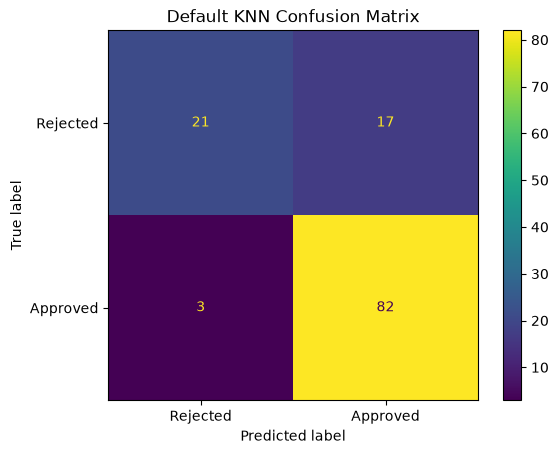

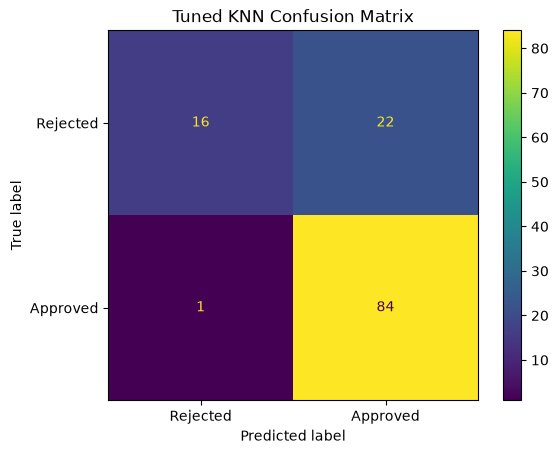


FINAL COMPARISON
Default KNN (K=5): 83.74%
KNN (K=3): 83.74%
KNN (K=5): 83.74%
KNN (K=7): 84.55%
Tuned KNN (K=18): 81.30%


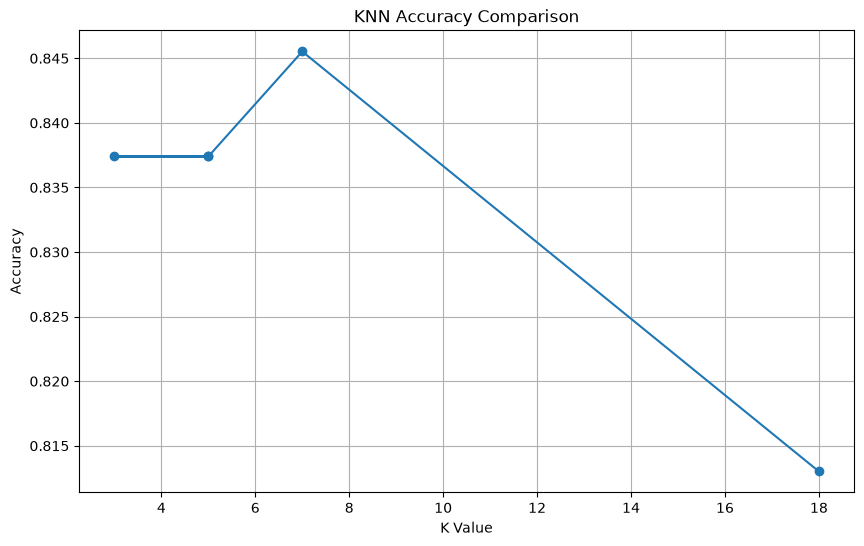

In [ ]:

# KNN LOAN PREDICTION PROJECT


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay



# 1. LOAD DATASET


df = pd.read_csv("train.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)



# 2. CHECK MISSING VALUES


print("\nMissing Values:")
print(df.isnull().sum())


# 3. REMOVE LOAN_ID

# Loan_ID is only an identifier and is not useful
# for predicting loan approval.

df = df.drop("Loan_ID", axis=1)


# 4. IDENTIFY COLUMNS


categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]


# 5. FILL MISSING VALUES


# Numerical columns -> median

for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )


# Categorical columns -> mode

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )


# 6. HANDLE DEPENDENTS


# Convert "3+" into 3

df["Dependents"] = df["Dependents"].replace(
    "3+", "3"
)

df["Dependents"] = df["Dependents"].astype(int)



# 7. ENCODE CATEGORICAL VARIABLES


# Convert categorical columns into numerical
# values using one-hot encoding.

df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Married",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)


# 8. ENCODE LOAN STATUS


# Y = Approved = 1
# N = Rejected = 0

df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})



# 9. SEPARATE FEATURES AND TARGET


X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]


print("\nFeatures:")
print(X.columns.tolist())



# 10. SPLIT DATA


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# 11. STANDARDIZE FEATURES


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



# 12. DEFAULT KNN MODEL


# KNeighborsClassifier() uses the default
# n_neighbors = 5

default_knn = KNeighborsClassifier()

default_knn.fit(
    X_train_scaled,
    y_train
)


# 13. DEFAULT KNN PREDICTION

default_predictions = default_knn.predict(
    X_test_scaled
)



# 14. DEFAULT KNN ACCURACY


default_accuracy = accuracy_score(
    y_test,
    default_predictions
)

print("\n================================")
print("DEFAULT KNN MODEL")
print("================================")

print("K:", default_knn.n_neighbors)

print(
    "Accuracy:",
    round(default_accuracy * 100, 2),
    "%"
)



# 15. TEST K = 3, 5, 7
print("\n================================")
print("K EXPERIMENT")
print("================================")

k_values = [3, 5, 7]

k_results = {}

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    k_results[k] = accuracy

    print(
        f"K = {k} | Accuracy = {accuracy * 100:.2f}%"
    )


# ============================================
# 16. HYPERPARAMETER TUNING
# ============================================

print("\n================================")
print("HYPERPARAMETER TUNING")
print("================================")

# Test different values of n_neighbors

parameter_grid = {
    "n_neighbors": range(1, 21)
}


grid_search = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(
    X_train_scaled,
    y_train
)


# 17. BEST PARAMETERS


best_k = grid_search.best_params_[
    "n_neighbors"
]

best_cv_accuracy = grid_search.best_score_


print("Best K:", best_k)

print(
    "Best Cross-Validation Accuracy:",
    round(best_cv_accuracy * 100, 2),
    "%"
)


# 18. FINAL TUNED KNN MODEL


tuned_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

tuned_knn.fit(
    X_train_scaled,
    y_train
)


# 19. TUNED KNN PREDICTION


tuned_predictions = tuned_knn.predict(
    X_test_scaled
)



# 20. TUNED KNN ACCURACY


tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

print("\n================================")
print("TUNED KNN MODEL")
print("================================")

print("Best K:", best_k)

print(
    "Test Accuracy:",
    round(tuned_accuracy * 100, 2),
    "%"
)


# 21. CONFUSION MATRICES


default_cm = confusion_matrix(
    y_test,
    default_predictions
)

tuned_cm = confusion_matrix(
    y_test,
    tuned_predictions
)


print("\n================================")
print("DEFAULT KNN CONFUSION MATRIX")
print("================================")

print(default_cm)


print("\n================================")
print("TUNED KNN CONFUSION MATRIX")
print("================================")

print(tuned_cm)



# 22. PLOT DEFAULT KNN CONFUSION MATRIX


disp1 = ConfusionMatrixDisplay(
    confusion_matrix=default_cm,
    display_labels=["Rejected", "Approved"]
)

disp1.plot()

plt.title("Default KNN Confusion Matrix")

plt.show()



# 23. PLOT TUNED KNN CONFUSION MATRIX


disp2 = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Rejected", "Approved"]
)

disp2.plot()

plt.title("Tuned KNN Confusion Matrix")

plt.show()


# 24. COMPARE RESULTS

print("\n================================")
print("FINAL COMPARISON")
print("================================")

print(
    f"Default KNN (K=5): "
    f"{default_accuracy * 100:.2f}%"
)

for k, accuracy in k_results.items():

    print(
        f"KNN (K={k}): "
        f"{accuracy * 100:.2f}%"
    )

print(
    f"Tuned KNN (K={best_k}): "
    f"{tuned_accuracy * 100:.2f}%"
)


# 25. ACCURACY COMPARISON GRAPH


all_k = [5] + k_values + [best_k]
all_accuracy = (
    [default_accuracy]
    + [k_results[k] for k in k_values]
    + [tuned_accuracy]
)

plt.figure(figsize=(10, 6))

plt.plot(
    all_k,
    all_accuracy,
    marker="o"
)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("KNN Accuracy Comparison")

plt.grid(True)

plt.show()